# 🎓 UC4 - Machine Learning e Data Mining (Analista de Dados)
## 🧪 Aula 04 - Classificação com KNN (K-Nearest Neighbors)

Nesta prática guiada, vamos aprender a classificar elementos utilizando o algoritmo KNN, a entender o impacto do hiperparâmetro K e a necessidade crítica de normalizar/padronizar as variáveis de escala.

---
### ⚙️ Passo 1: Importando Bibliotecas e Carregando os Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Carregando o dataset Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("Iris carregado com sucesso!")
X.head()

Iris carregado com sucesso!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


---
### ✂️ Passo 2: Divisão de Treino e Teste (Split)
Vamos separar 70% dos dados para treinamento e 30% para teste.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 105 amostras
Teste: 45 amostras


---
### 🛡️ Passo 3: Padronização das Escalas (StandardScaler)
O KNN calcula distâncias geométricas. Por isso, precisamos deixar todas as features na mesma escala (média 0 e desvio padrão 1).

In [3]:
# Instanciar o padronizador
scaler = StandardScaler()

# Ajustar no treino e transformar treino e teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualizando o resultado padronizado
pd.DataFrame(X_train_scaled, columns=iris.feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.413416,-1.462003,-0.099511,-0.323398
1,0.551222,-0.502563,0.717703,0.353032
2,0.671802,0.217016,0.951192,0.758890
3,0.912961,-0.022844,0.309096,0.217746
4,1.636440,1.416315,1.301427,1.705891


---
### 🤖 Passo 4: Treinando o KNN com K=5

In [4]:
# 1. Instanciar o modelo
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Treinar o modelo com os dados normalizados
knn.fit(X_train_scaled, y_train)

# 3. Fazer predições na base de teste
y_pred = knn.predict(X_test_scaled)

# 4. Avaliar com Acurácia Básica
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do KNN (K=5): {acuracia:.4f} ({acuracia * 100:.1f}%)")

Acurácia do KNN (K=5): 1.0000 (100.0%)


---
### ⚖️ Passo 5: O Efeito do Hiperparâmetro K
Vamos testar diferentes valores de vizinhos para ver como a acurácia se comporta.

K = 01 -> Acurácia = 0.9778
K = 03 -> Acurácia = 1.0000
K = 05 -> Acurácia = 1.0000
K = 09 -> Acurácia = 1.0000
K = 15 -> Acurácia = 1.0000
K = 21 -> Acurácia = 1.0000
K = 31 -> Acurácia = 0.9111
K = 51 -> Acurácia = 0.8444


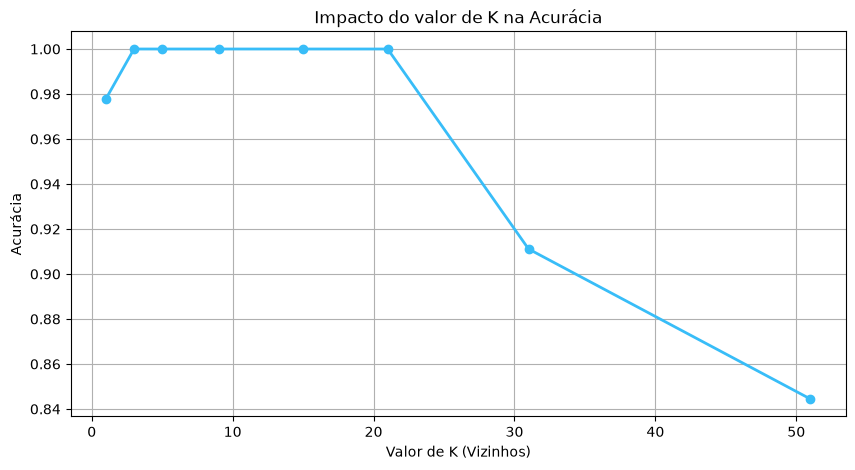

In [5]:
valores_k = [1, 3, 5, 9, 15, 21, 31, 51]
acuracias = []

for k in valores_k:
    modelo_teste = KNeighborsClassifier(n_neighbors=k)
    modelo_teste.fit(X_train_scaled, y_train)
    pred = modelo_teste.predict(X_test_scaled)
    ac = accuracy_score(y_test, pred)
    acuracias.append(ac)
    print(f"K = {k:02d} -> Acurácia = {ac:.4f}")

# Plotando a variação
plt.figure(figsize=(10, 5))
plt.plot(valores_k, acuracias, marker='o', color='#38bdf8', linewidth=2)
plt.title("Impacto do valor de K na Acurácia")
plt.xlabel("Valor de K (Vizinhos)")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

---
### 🚨 Passo 6: O Impacto de Ignorar a Escala de Dados
Vamos treinar o mesmo KNN (K=5) mas agora usando os dados brutos (`X_train` e `X_test` sem StandardScaler) para provar o impacto empírico da normalização de distâncias.

In [6]:
# Treinar nos dados brutos
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)

# Prever nos dados brutos
y_pred_raw = knn_raw.predict(X_test)

# Avaliar
acuracia_raw = accuracy_score(y_test, y_pred_raw)
print(f"Acurácia SEM normalização: {acuracia_raw:.4f}")
print(f"Diferença de performance: {(acuracia - acuracia_raw)*100:.2f}%")

Acurácia SEM normalização: 1.0000
Diferença de performance: 0.00%
